In [2]:
!pip install mplsoccer matplotlib numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.1 MB/s eta 0:00:00


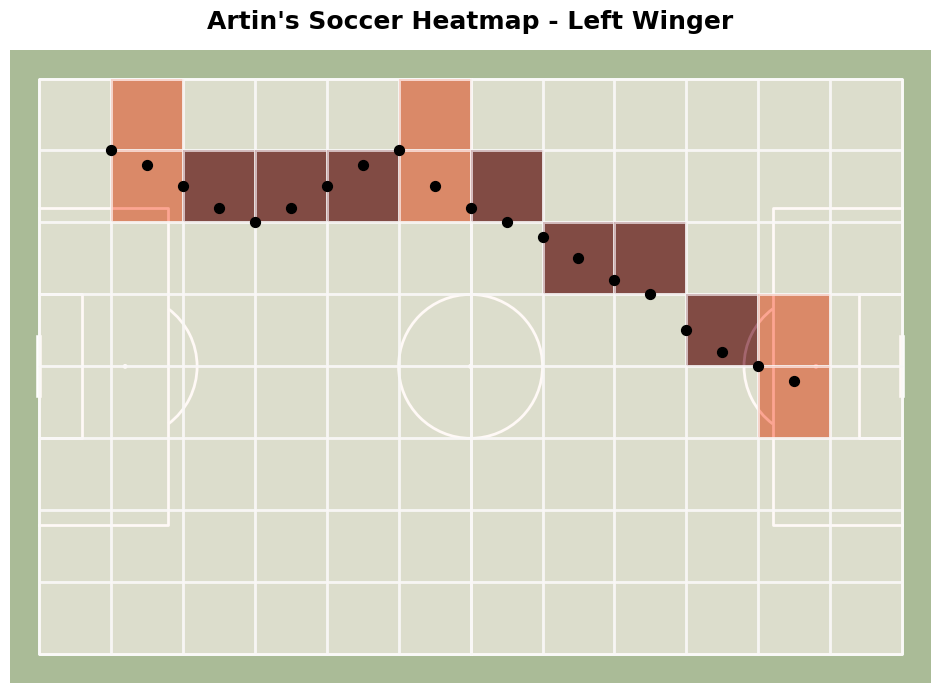

In [4]:
#Level 2 — Position-Based Player
## Goal: Choose your position.
### task: Change the coordinates based on your position after each game.

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

# 1. Create a professional soccer pitch layout
pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# 2. Simulate some ball touch data (X: 0 to 120 yards, Y: 0 to 80 yards)
# First, Let's pretend he is a left-winger who cuts inside toward the box

player = "Artin"
position = "Left Winger"

if position == "Left Winger":

    x_coordinates = [10,15,20,25,30,35,40,45,50,55, 60,65,70,75,80,85,90,95,100,105]
    y_coordinates = [10,12,15,18,20,18,15,12,10,15,18,20,22,25,28,30,35,38,40,42]

elif position == "Striker":

    x_coordinates = [70,75,80,85,90,95,100,102,105,108,110,112,115,108,104,100,95,90,88,110]
    y_coordinates = [35,38,40,42,40,38,35,37,40,42,39,36,40,45,48,50,45,42,38,35]

elif position == "Midfielder":

    x_coordinates = [35,40,45,50,55,60,65,70,60,55,50,45,40,55,65,75,70,60,50,45]
    y_coordinates = [25,30,35,40,45,40,35,30,25,20,25,30,35,45,50,45,40,35,30,25]

elif position == "Right Defender":

    # Modern attacking fullback
    # Defends deep but frequently overlaps on the right wing

    x_coordinates = [15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110]
    y_coordinates = [70,72,68,70,72,74,76,74,72,70,68,70,72,74,76,72,68,65,60,55]

# 3. Plot the touches as a heatmap (2D Histogram)
bin_statistic = pitch.bin_statistic(x_coordinates, y_coordinates, statistic='count', bins=(12, 8))
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.6)

# 4. Draw the individual touch points on top so he sees how it connects
pitch.scatter(x_coordinates, y_coordinates, c='black', s=50, ax=ax, label='Ball Touches')

plt.title(
    f"{player}'s Soccer Heatmap - {position}",
    fontsize=18,
    fontweight='bold',
    pad=15
)
plt.show()

Passing Accuracy: 75.0 %
Shooting Accuracy: 50.0 %


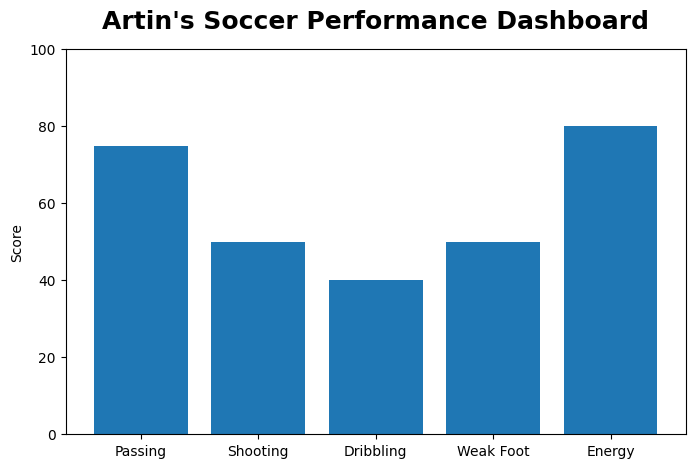

In [5]:
#Level 3 — Soccer Data Tracker
##Goal: Track simple performance data. You can change the numbers after each game and track your performance.

player_stats = {
    "passes_attempted": 20,
    "passes_completed": 15,
    "shots": 6,
    "shots_on_target": 3,
    "successful_dribbles": 4,
    "weak_foot_actions": 5,
    "energy_level": 4
}

passing_accuracy = player_stats["passes_completed"] / player_stats["passes_attempted"] * 100
shooting_accuracy = player_stats["shots_on_target"] / player_stats["shots"] * 100

print("Passing Accuracy:", round(passing_accuracy, 1), "%")
print("Shooting Accuracy:", round(shooting_accuracy, 1), "%")


import matplotlib.pyplot as plt

skills = ["Passing", "Shooting", "Dribbling", "Weak Foot", "Energy"]
scores = [
    passing_accuracy,
    shooting_accuracy,
    player_stats["successful_dribbles"] * 10,
    player_stats["weak_foot_actions"] * 10,
    player_stats["energy_level"] * 20
]

plt.figure(figsize=(8, 5))
plt.bar(skills, scores)
plt.title(f"{player}'s Soccer Performance Dashboard",fontsize=18,
    fontweight='bold',
    pad=15)
plt.ylabel("Score")
plt.ylim(0, 100)
plt.show()

In [ ]:
!pip install google-genai

In [6]:

#Level 4 — AI Soccer Coach
##Goal: Feed the stats into Gemini.
### Task: Check your match_report_data, and define your coach style. It could be a "friendly academy coach",
### or "elite youth soccer academy scout and tactical coach", or "strict Italian tactical coach" and run the code.

from google import genai
from google.colab import userdata

# Retrieve the API key from your Colab secrets securely
api_key = userdata.get('JULY-KEY')
client = genai.Client(api_key=api_key)

# 1. Define the match data context as text for the AI
player = "Artin"
age = 15

match_report_data = f"""
Player: {player}
Age: {age}
Position: {position}

Touch Map:
- X coordinates: {x_coordinates}
- Y coordinates: {y_coordinates}

Performance Stats:
- Passing accuracy: {round(passing_accuracy, 1)}%
- Shooting accuracy: {round(shooting_accuracy, 1)}%
- Successful dribbles: {player_stats["successful_dribbles"]}
- Weak foot actions: {player_stats["weak_foot_actions"]}
- Energy level: {player_stats["energy_level"]}/5

Video Notes:
- Add observations from extracted frames here.
"""

# 2. Instruct the AI Agent on its specific role and personality
coach_style = "friendly academy coach"
##coach_style = "elite youth soccer academy scout and tactical coach"
##coach_style = "strict Italian tactical coach"
system_instruction = f"""
You are a {coach_style} for a {age}-year-old soccer player.
Your goal is to look at match data and provide constructive, highly motivating,
and technically accurate feedback for {player}. Use modern soccer
terminology such as half-spaces, low-block, transition phase, and scanning.

Your job:
1. Analyze soccer data.
2. Explain patterns simply.
3. Give tactical feedback.
4. Suggest realistic drills.
5. Stay encouraging, not harsh.
6. Avoid pretending the data proves more than it really does.

Use soccer terms like:
- scanning
- first touch
- half-space
- transition
- weak foot
- off-ball movement
- decision-making

Format your answer as:
1. Player Summary
2. Strengths
3. Improvement Areas
4. Training Plan
5. Pro Player Homework
6. Motivation
"""


# 3. Trigger the Agent
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=f"Analyze this match data and give me 3 strengths, 2 tactical areas to improve, and 1 pro player to watch for homework:\n\n{match_report_data}",
    config={'system_instruction': system_instruction}
)

print(response.text)

Alright Artin, great to see you're ready to dig into your performance and keep pushing your game forward! That's the mindset of a top player, always looking for ways to improve. I've gone through your match data from the last game, and there's a lot of exciting stuff here to talk about.

As a left winger, you're a key player for us, bringing that directness and creativity. Let's break down what the data shows, what you did brilliantly, and where we can fine-tune things to make you even more effective on the pitch.

---

### 1. Player Summary

Artin, you're a dynamic left winger with a strong attacking presence and an impressive ability to use both feet. Your energy and willingness to take on defenders make you a constant threat in the final third. The data highlights a player who is actively involved, versatile in movement, and possesses key attributes that make defenders think twice.

---

### 2. Strengths

Here are three areas where you really stood out in the last game:

1.  **Excep